In [40]:
import pandas as pd
import os
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pandas.api.types import is_numeric_dtype

In [29]:
def predict(models, test):
  predict = pd.Series(index=test.index, data=np.zeros(test.shape[0]))
  models_len = len(models)
  for model in models:
    predict += (
        model.predict(
            test[model.feature_name()]
        )
        / models_len
    )
  return predict

In [7]:
project_path = "/content/drive/MyDrive/Colab Notebooks/scorewarrior"
data_path = f"{project_path}/data"

# Load data

In [116]:
train = pd.read_csv(f"{data_path}/train.csv")
test = pd.read_csv(f"{data_path}/test.csv")

In [117]:
class_path = f"{project_path}/artifacts/final/classificator"
regr_path = f"{project_path}/artifacts/final/regressor"

In [118]:
classificators = []
regressors = []
for fold in range(5):
  class_model = lgb.Booster(model_file=f"{class_path}/model_{fold}.txt")
  classificators.append(class_model)
  regr_model = lgb.Booster(model_file=f"{regr_path}/model_{fold}.txt")
  regressors.append(regr_model)

# Скор

In [119]:
test['bin_pred'] = predict(classificators, test)
test['tweedie_pred'] = predict(regressors, test)

In [120]:
test['f_Interval_sum_payment_prev7days_f'] = test['f_Interval_sum_payment_prev7days'].fillna(0)
test['tweedie_pred_t'] = (test['bin_pred']*np.round(test['tweedie_pred'], 9))
test['tweedie_pred_t'] = test[['tweedie_pred_t', 'f_Interval_sum_payment_prev7days_f']].max(1)
test.loc[test['tweedie_pred_t'] <1, 'tweedie_pred_t'] = 0

In [121]:
test['base_pred'] = test['f_Interval_sum_payment_prev7days_f'] + test['bin_pred']*test['f_Interval_sum_payment_prev7days_f']

# Сверка по фичам и скору

In [122]:
def _psi(a, b, bins=10, eps=1e-6):
    if len(np.unique(a)) < 2: return np.nan
    q = np.linspace(0, 1, bins+1)
    edges = np.unique(np.quantile(a, q))
    if len(edges) < 3:
        lo, hi = np.nanmin(a), np.nanmax(a)
        if not np.isfinite(lo) or lo==hi: return np.nan
        edges = np.linspace(lo, hi, bins+1)
    h1,_ = np.histogram(a, bins=edges); h2,_ = np.histogram(b, bins=edges)
    p, q = h1/ max(h1.sum(),1), h2/ max(h2.sum(),1)
    p, q = np.clip(p, eps, 1), np.clip(q, eps, 1)
    return float(np.sum((p-q)*np.log(p/q)))

def psi_report(train, test, features=None, psi_bins=5, bins=30, dropna=True, figsize=(15,8)):
    if features is None: features = sorted(set(train.columns)&set(test.columns))
    rows=[]
    for col in features:
        if not (is_numeric_dtype(train[col]) and is_numeric_dtype(test[col])): continue
        a = pd.to_numeric(train[col], errors='coerce').replace([np.inf,-np.inf], np.nan)
        b = pd.to_numeric(test[col],  errors='coerce').replace([np.inf,-np.inf], np.nan)
        if dropna: a, b = a.dropna(), b.dropna()
        psi = _psi(a.values, b.values, bins=psi_bins) if (len(a) and len(b)) else np.nan
        rows.append({"feature": col, "psi": psi})

        plt.figure(figsize=figsize)
        plt.hist(a, bins=bins, density=True, alpha=.5, label='train')
        plt.hist(b, bins=bins, density=True, alpha=.5, label='test')
        plt.title(f"{col} | PSI={psi:.3f}"); plt.legend(); plt.tight_layout(); plt.show()
    return pd.DataFrame(rows).sort_values("psi", ascending=False).reset_index(drop=True)

In [123]:
features = list(set(classificators[0].feature_name() + regressors[0].feature_name()))

<Axes: xlabel='f_Interval_sum_payment_prev7days_f', ylabel='Density'>

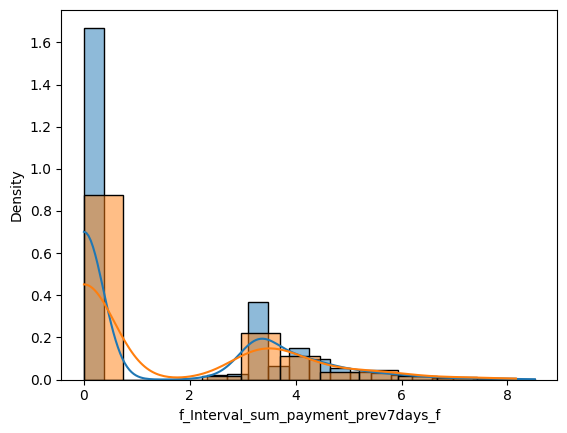

In [132]:
sns.histplot(np.log1p(train['f_Interval_sum_payment_prev7days_f']), kde=True, stat="density", label='train')
sns.histplot(np.log1p(test['f_Interval_sum_payment_prev7days_f']), kde=True, stat="density", label='test')

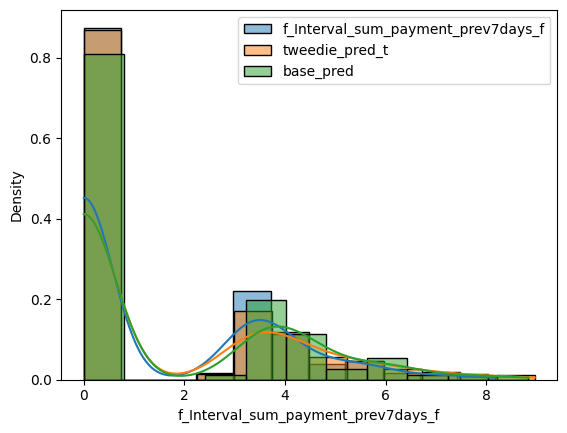

In [131]:
import seaborn as sns
sns.histplot(np.log1p(test['f_Interval_sum_payment_prev7days_f']), kde=True, stat="density", label='f_Interval_sum_payment_prev7days_f')
sns.histplot(np.log1p(test['tweedie_pred_t']), kde=True, stat="density", label='tweedie_pred_t')
sns.histplot(np.log1p(test['base_pred']), kde=True, stat="density", label='base_pred')
plt.legend()
plt.show()

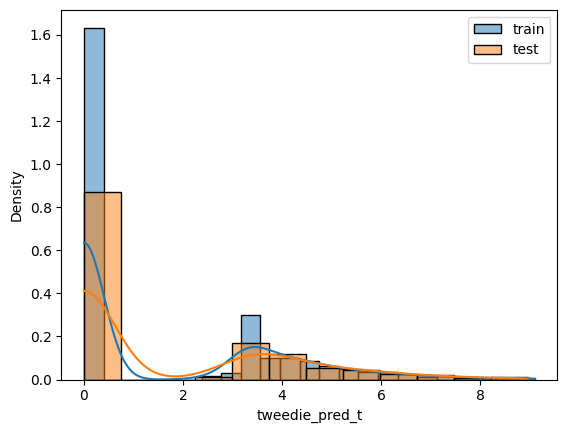

In [130]:
sns.histplot(np.log1p(train['tweedie_pred_t']), kde=True, stat="density", label='train')
sns.histplot(np.log1p(test['tweedie_pred_t']), kde=True, stat="density", label='test')
plt.legend()
plt.show()

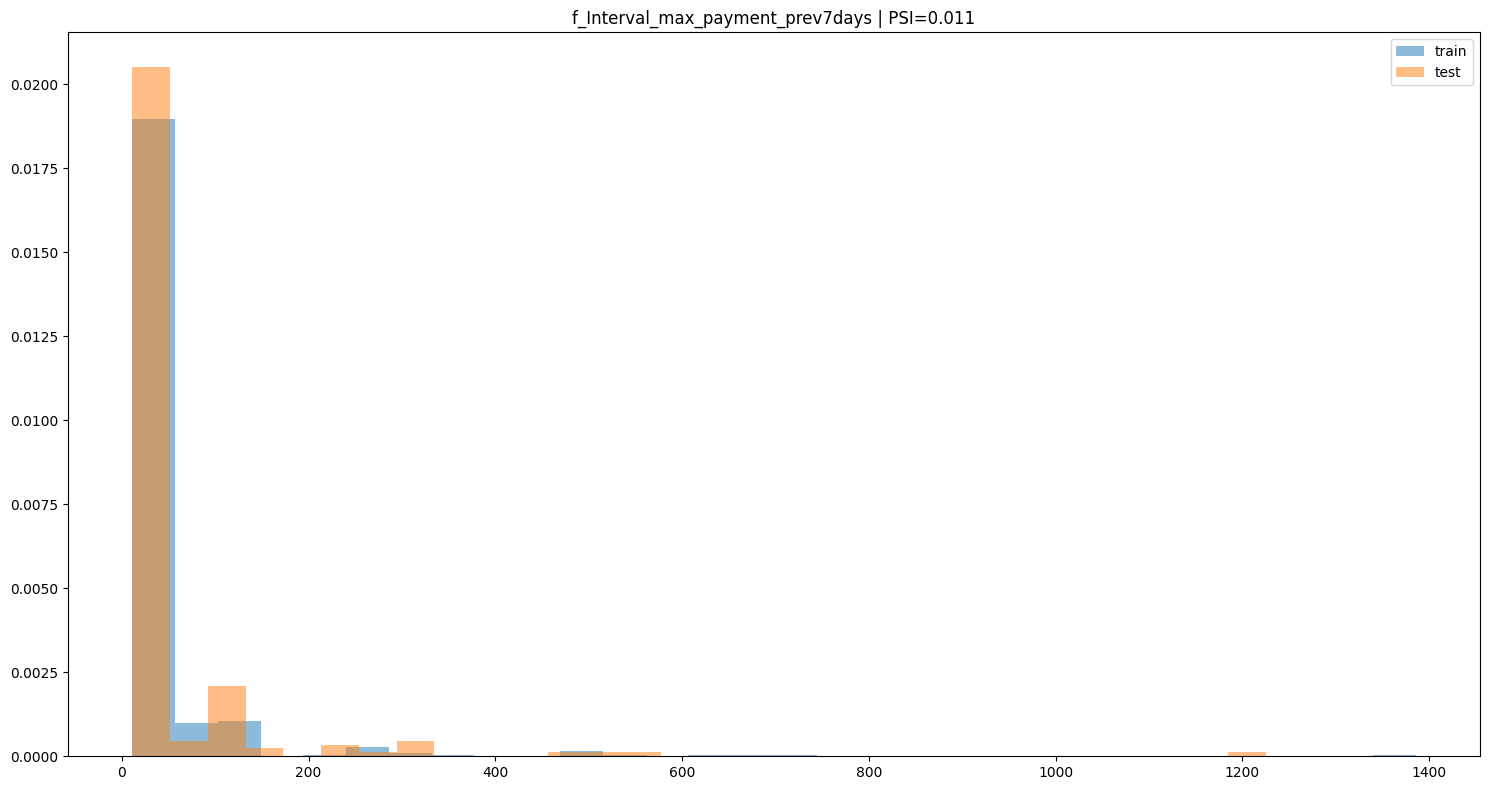

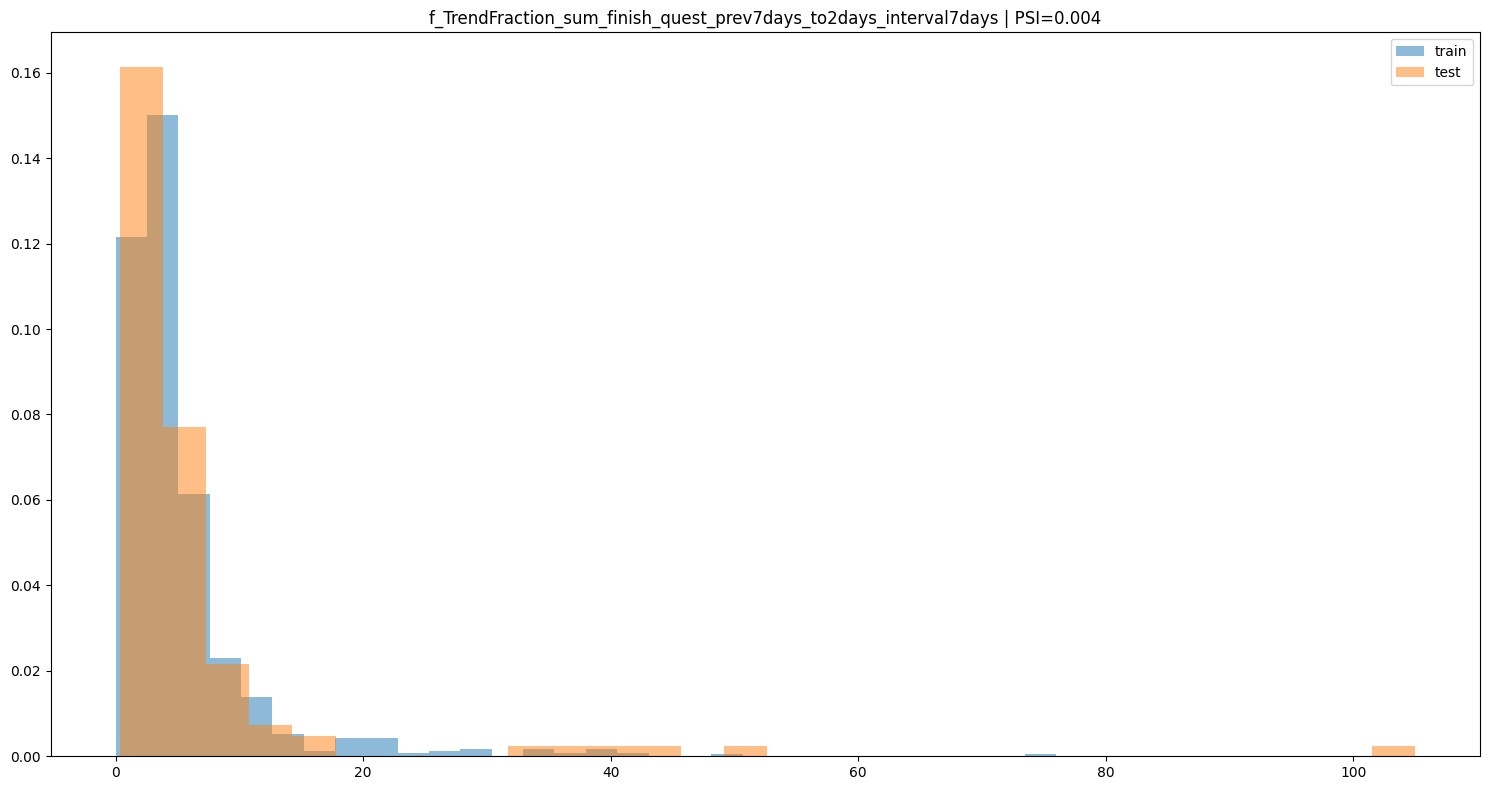

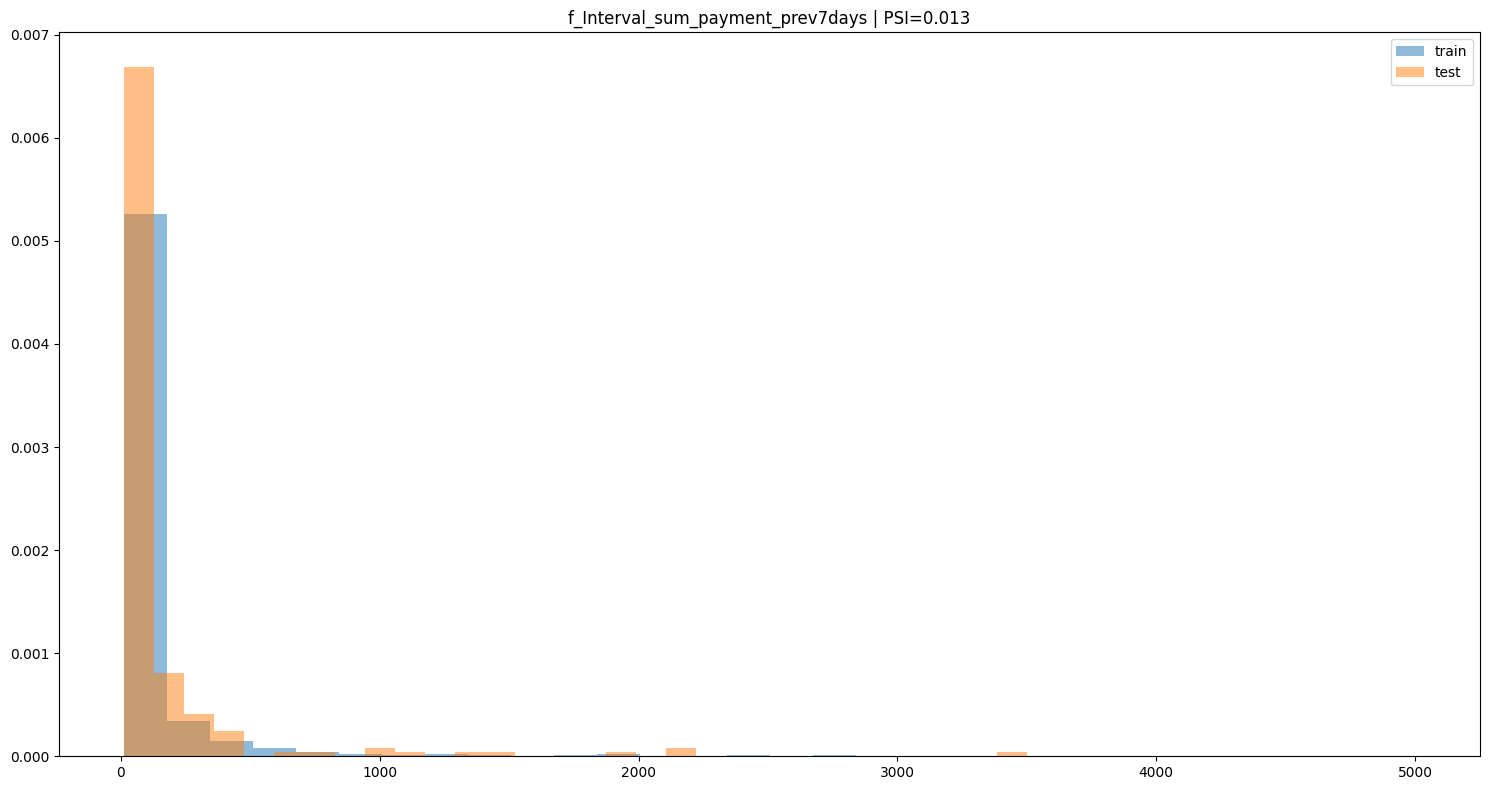

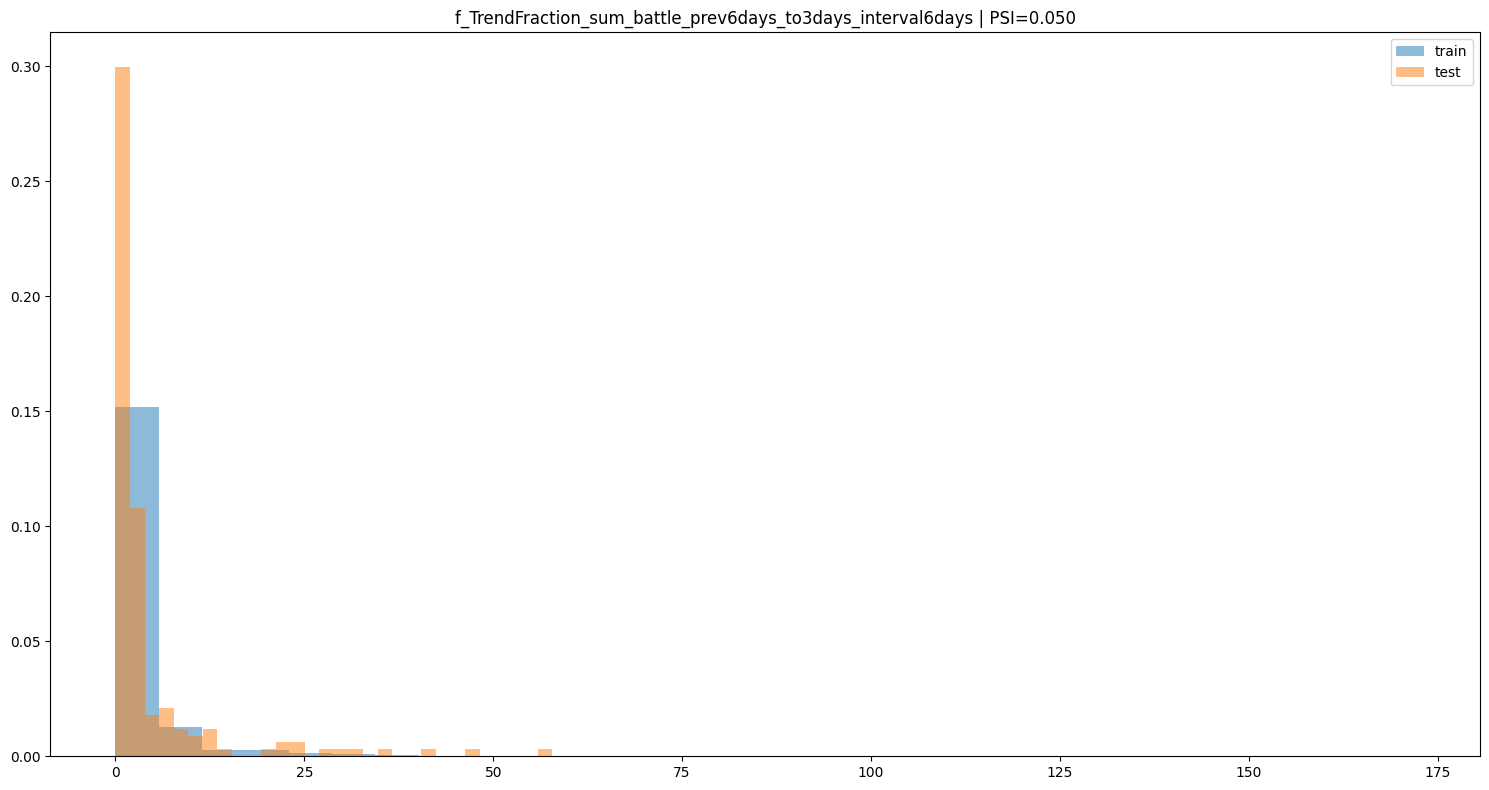

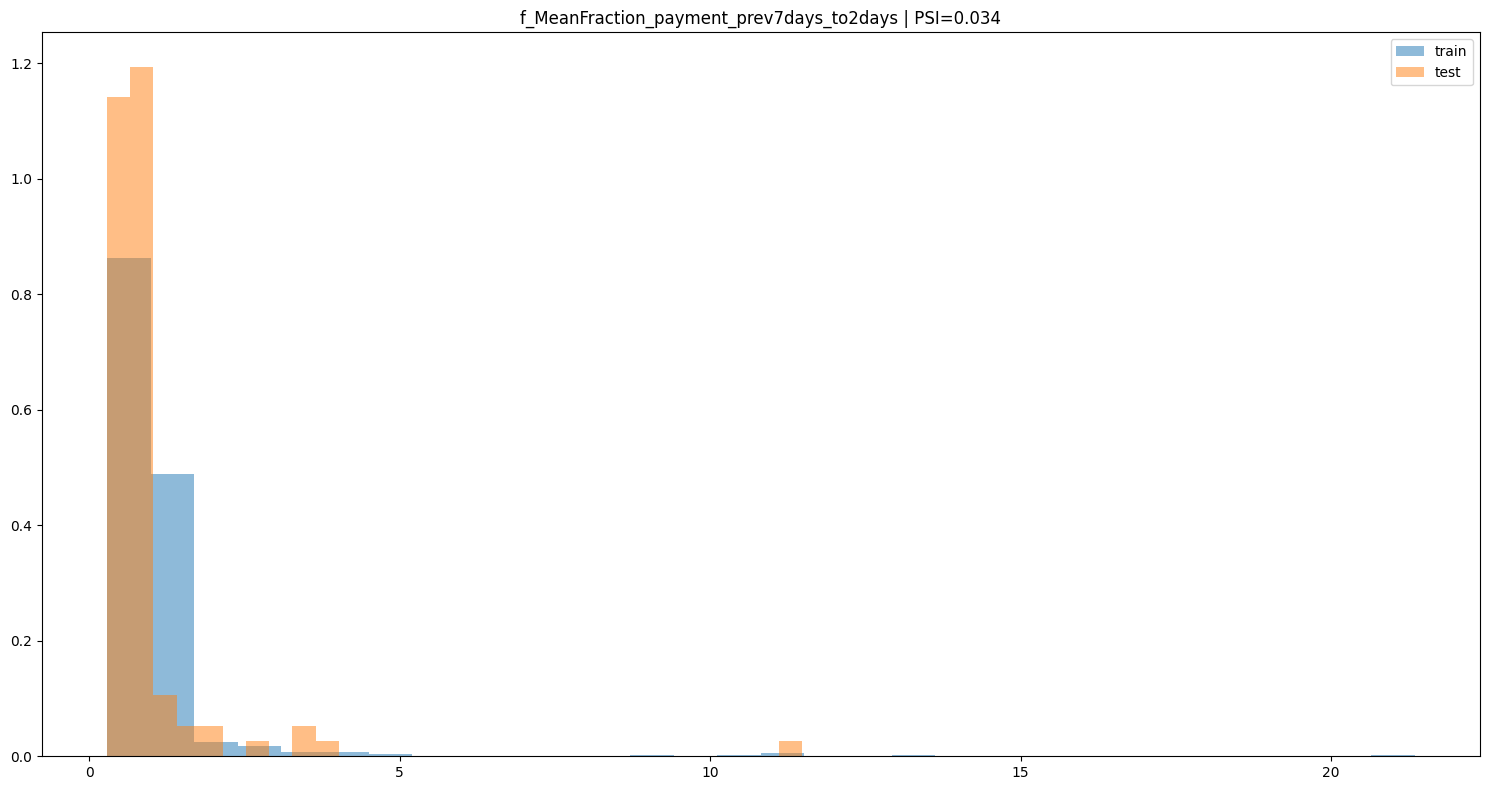

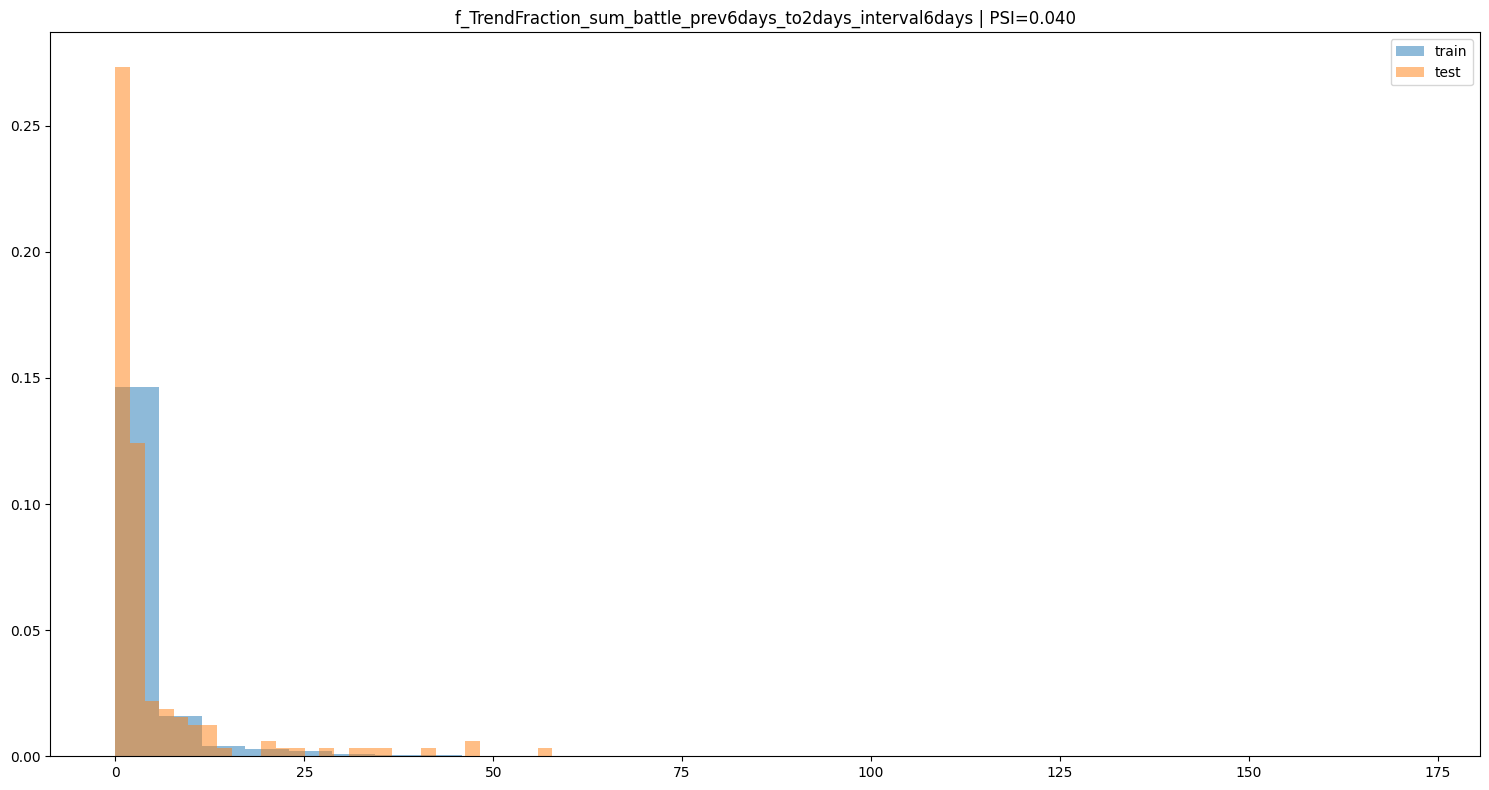

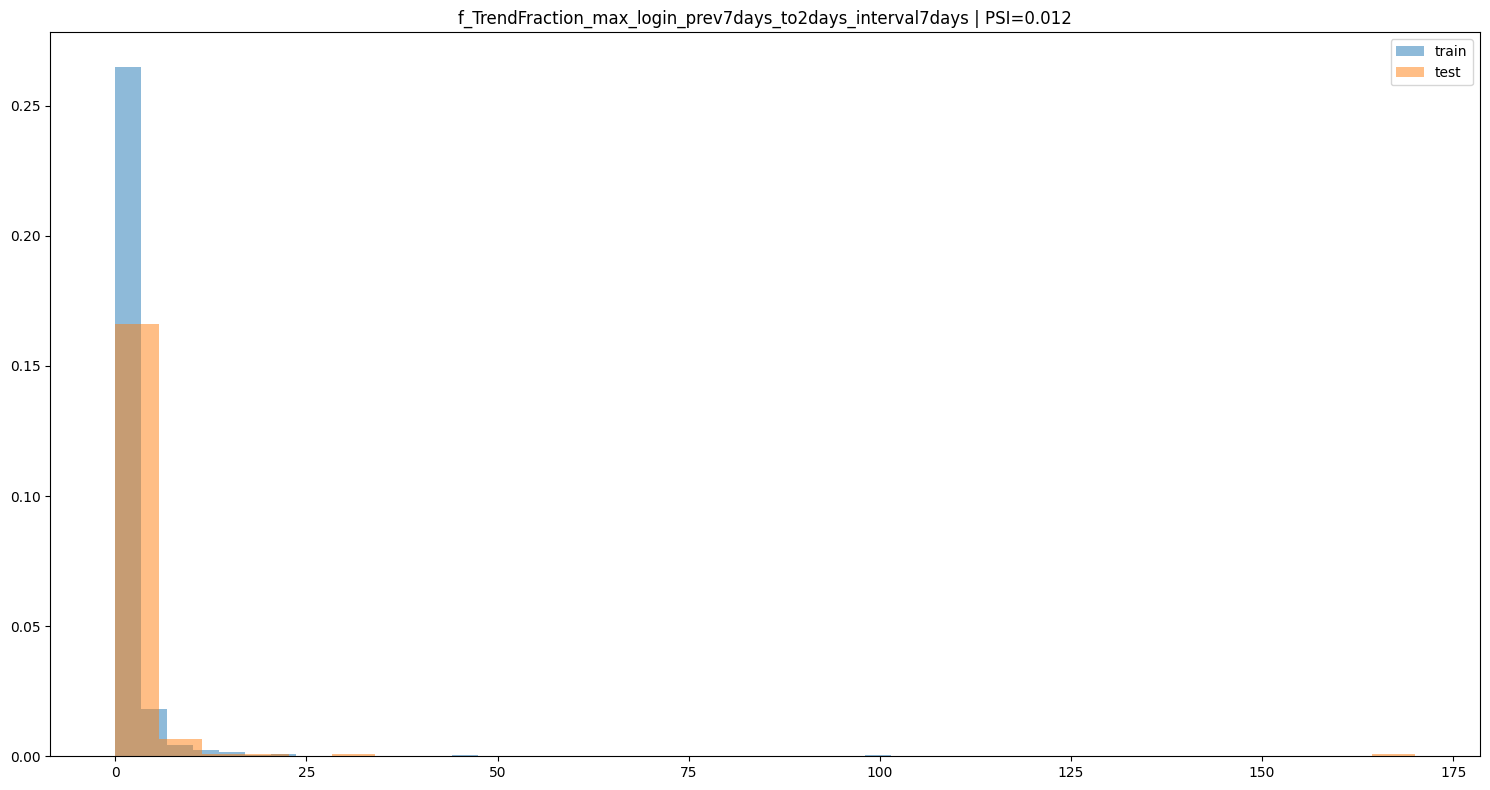

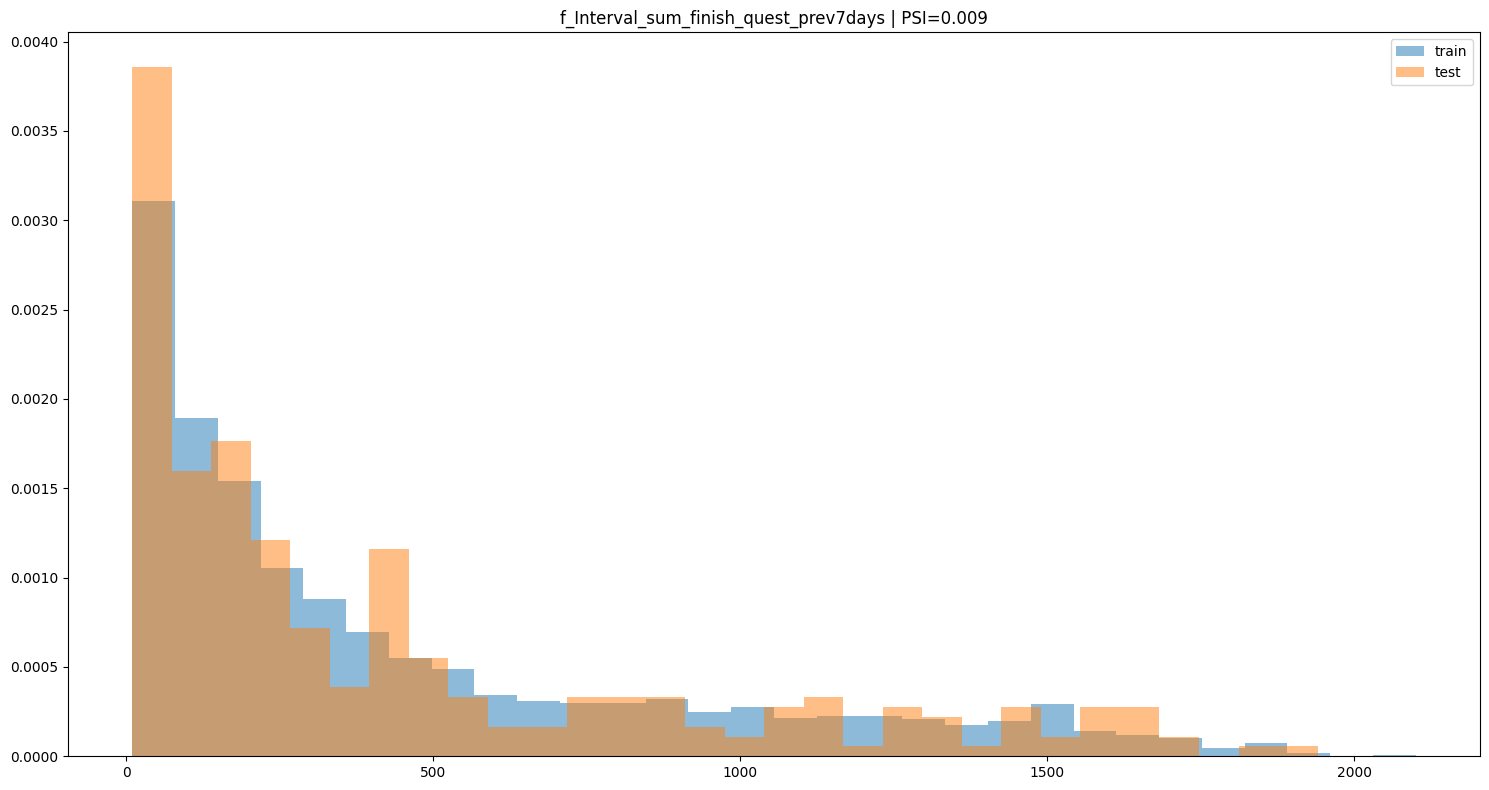

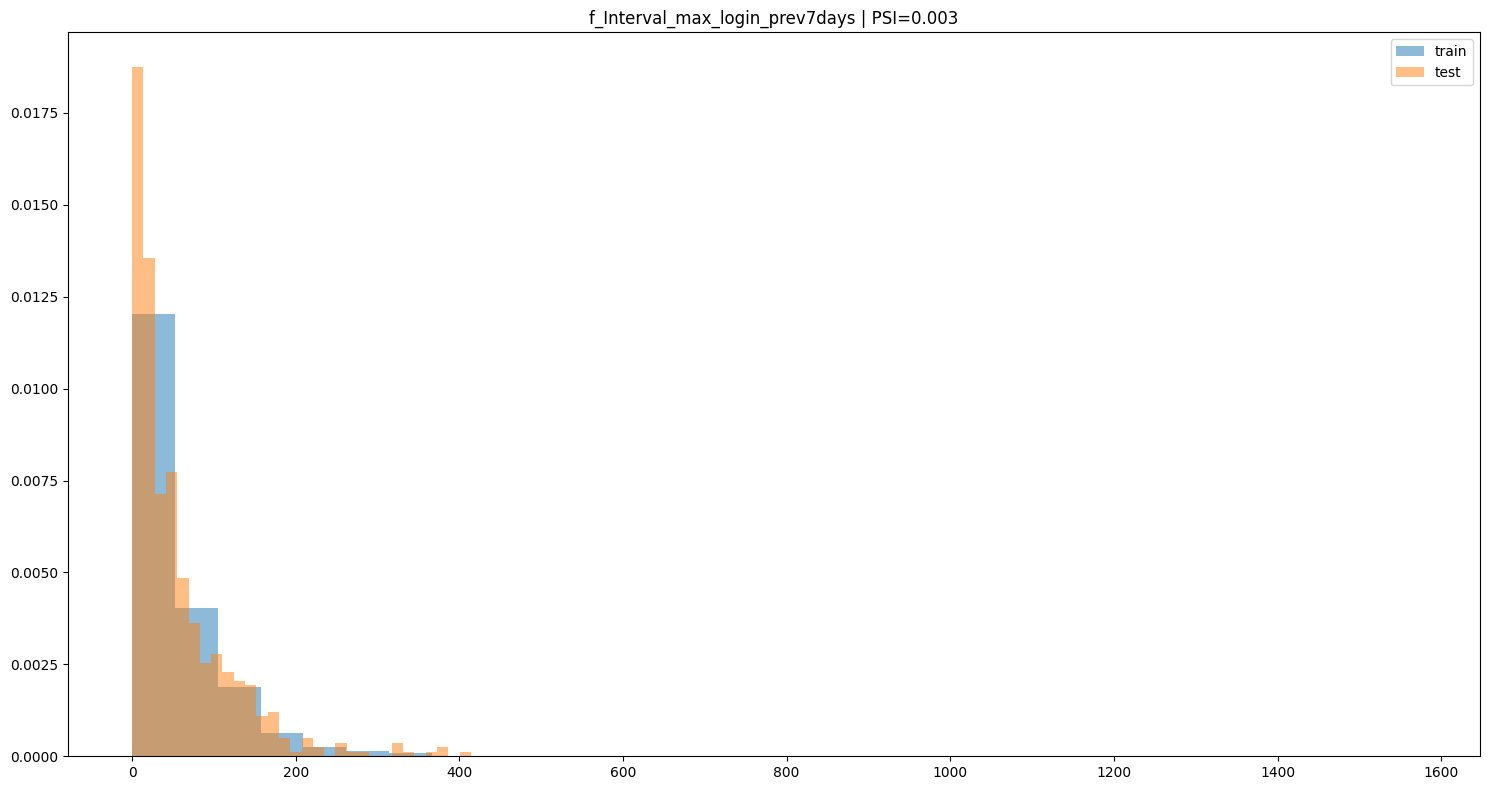

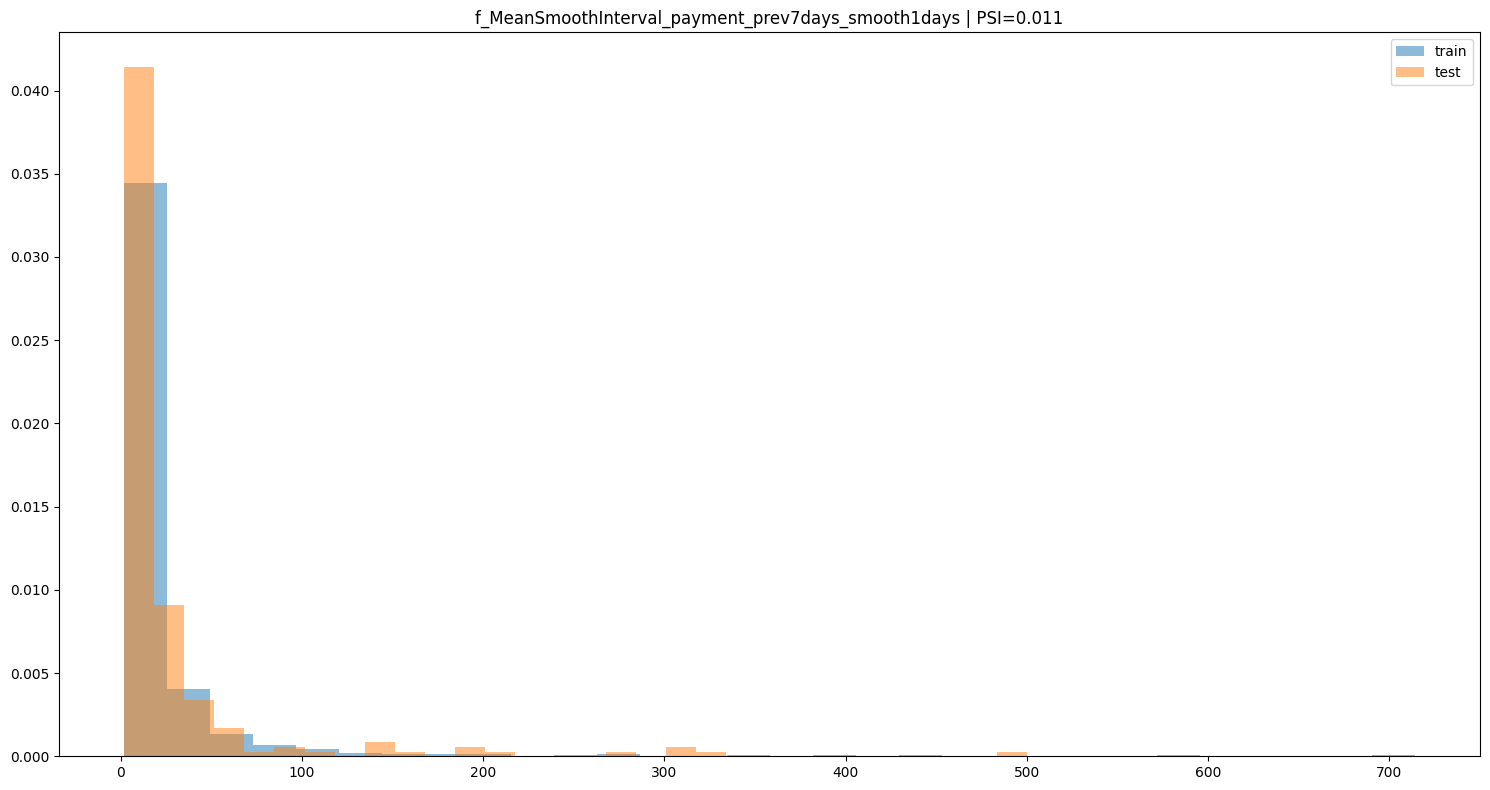

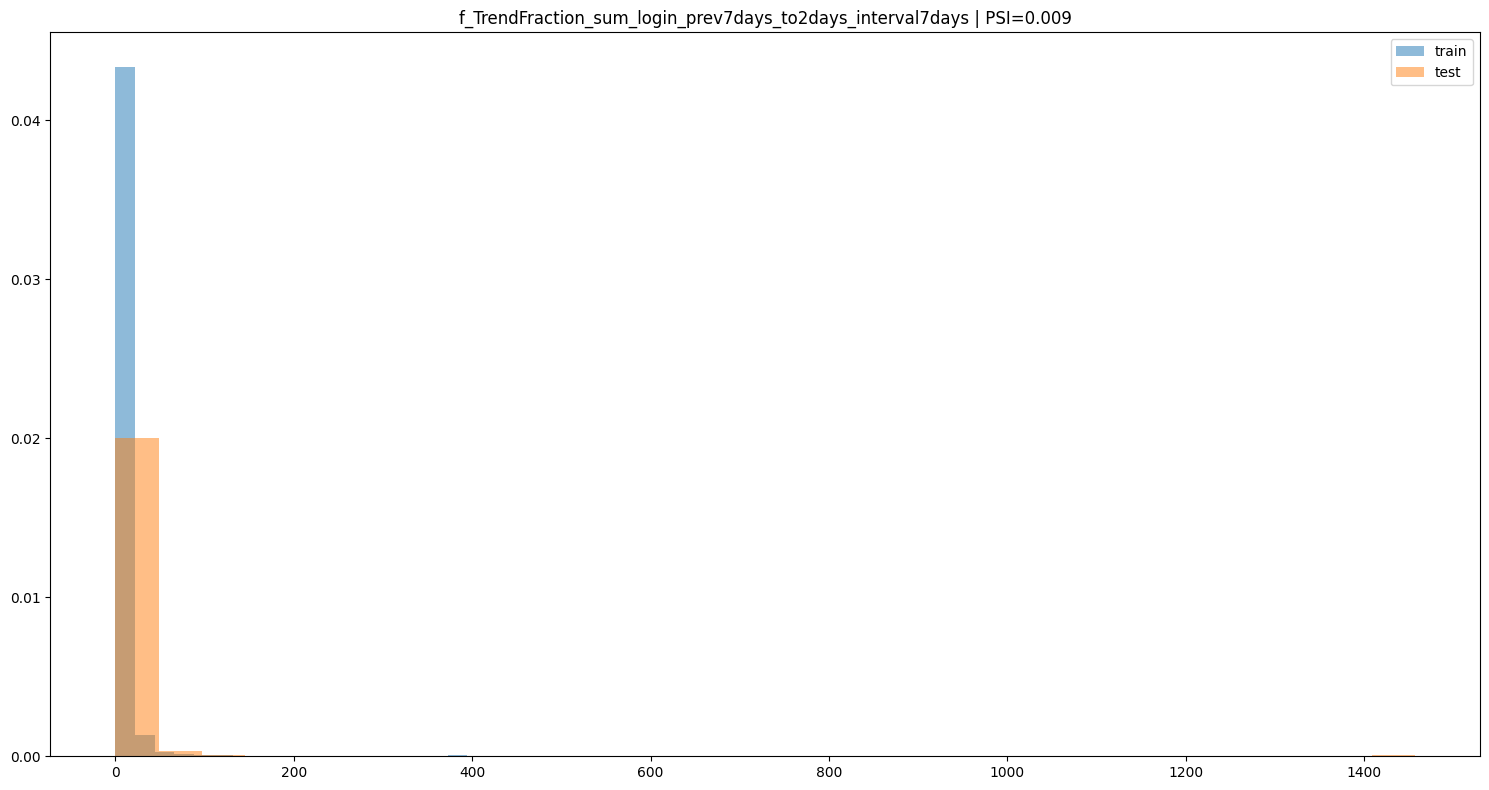

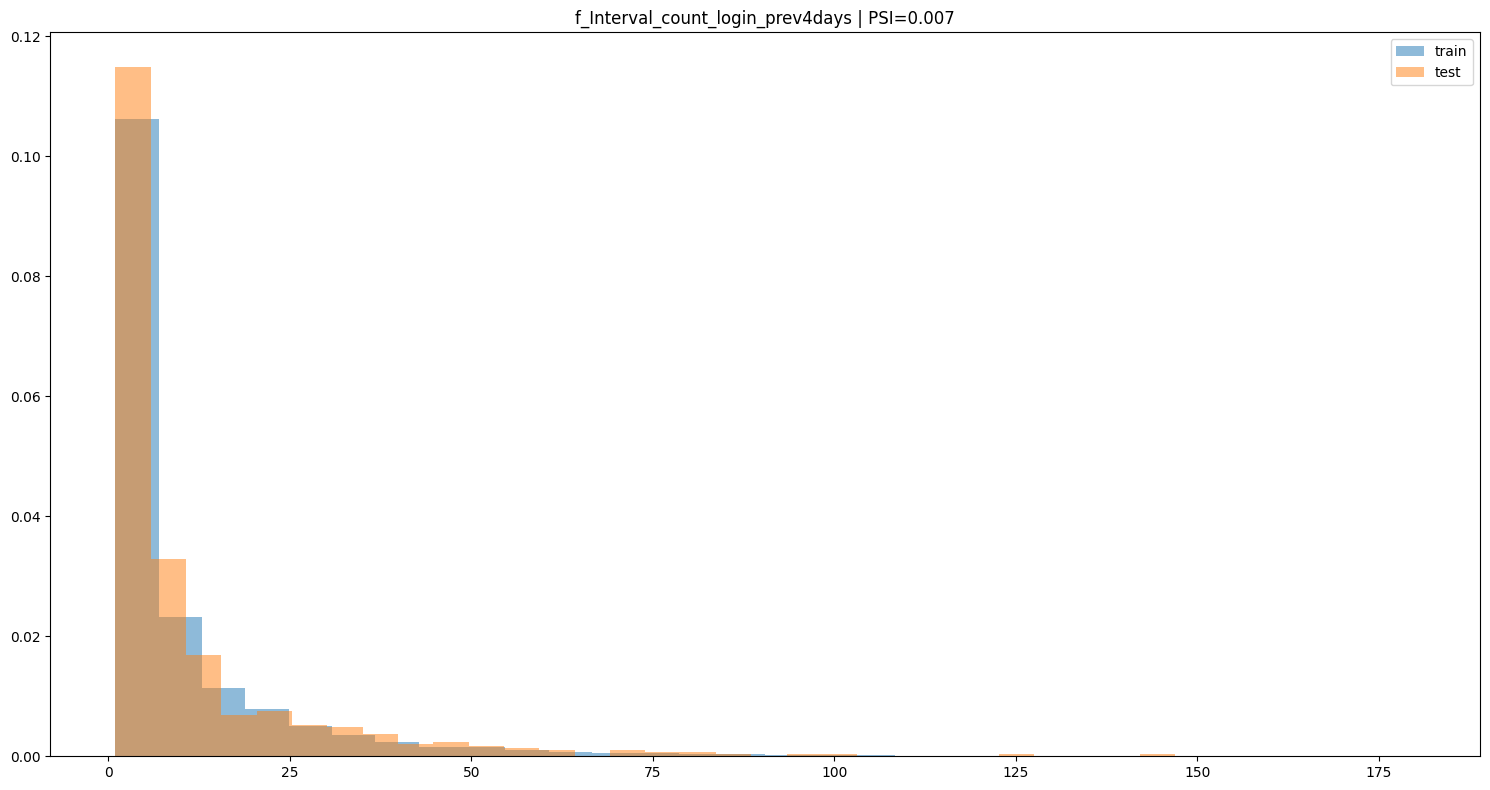

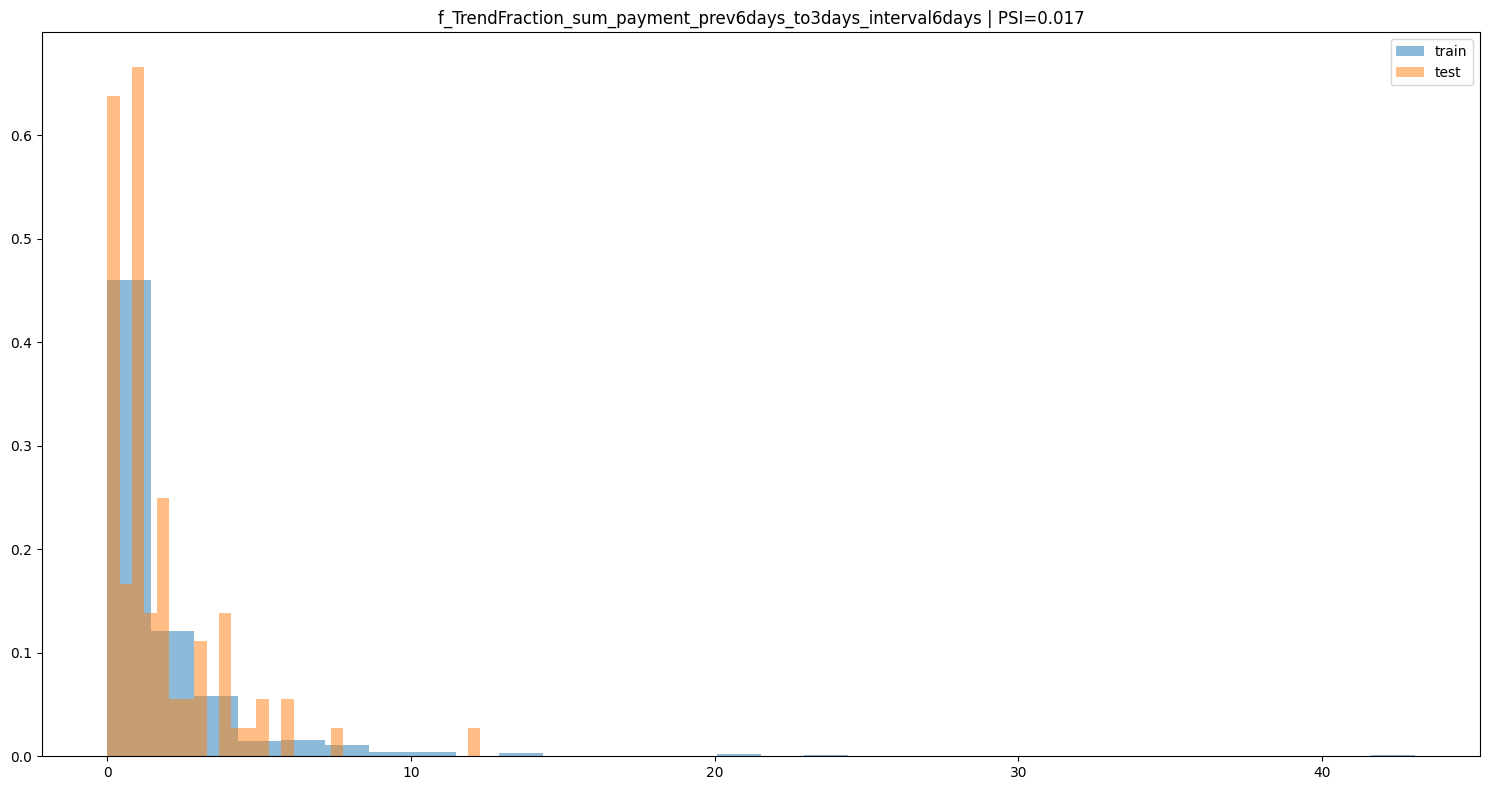

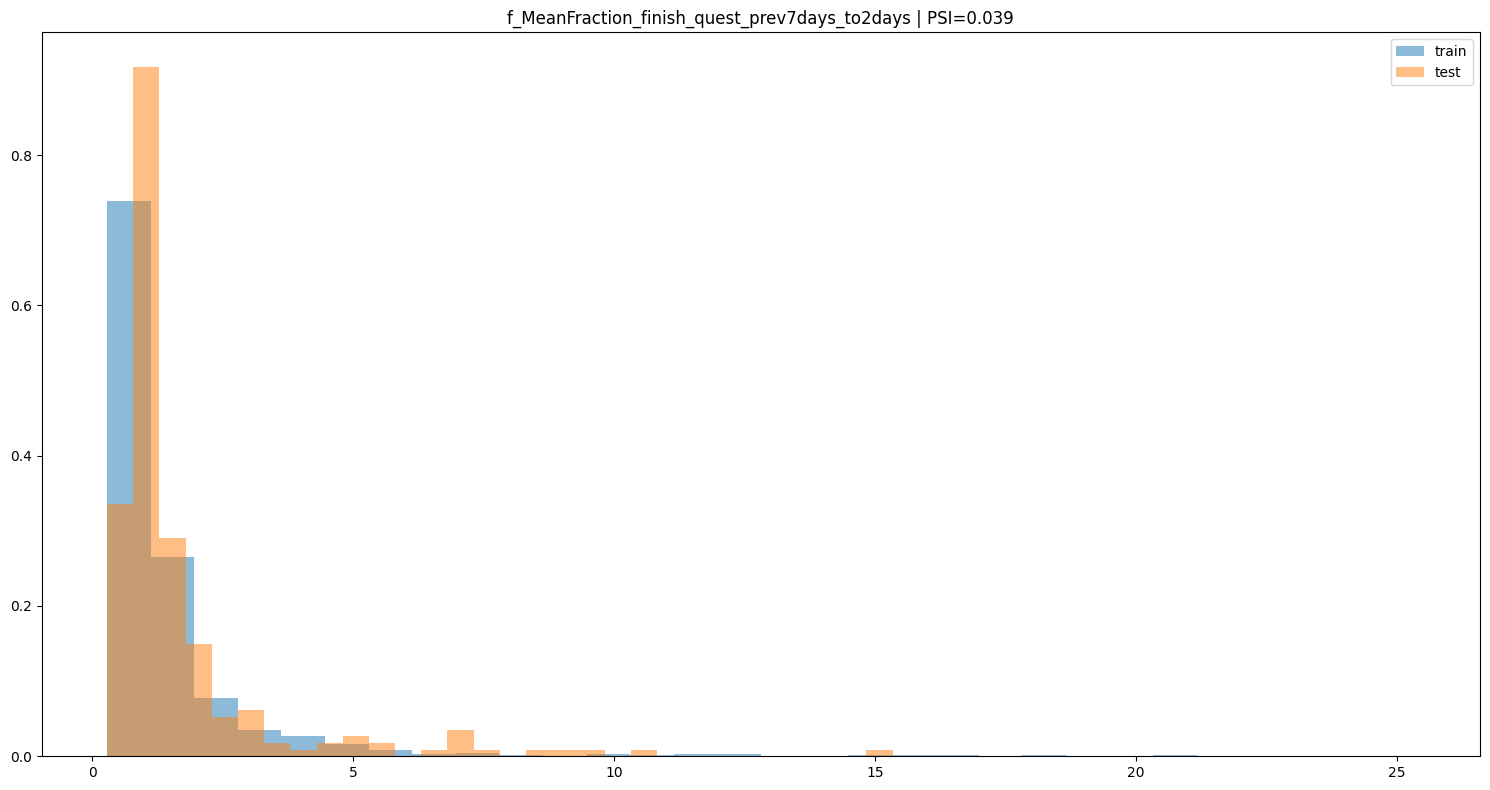

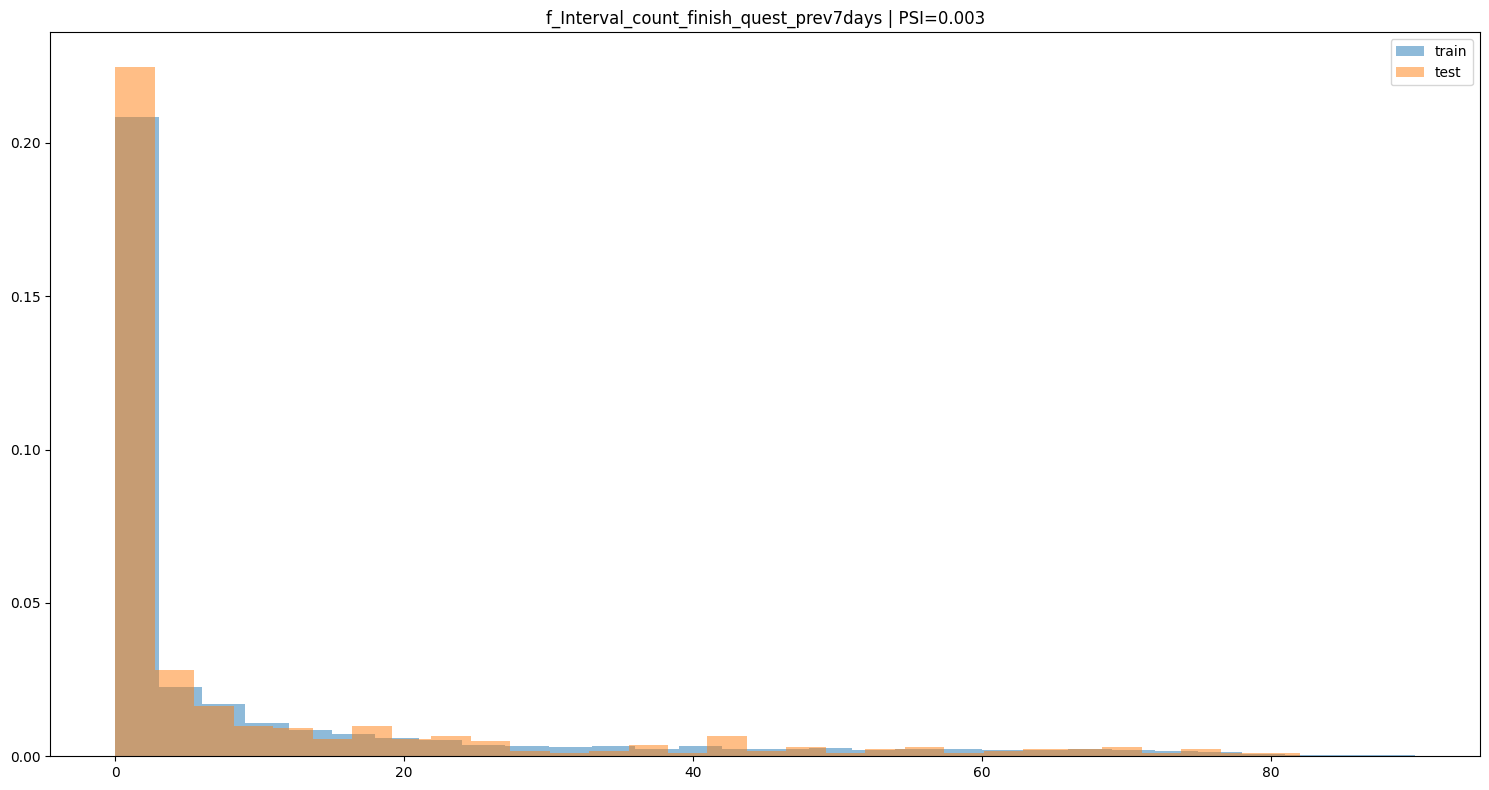

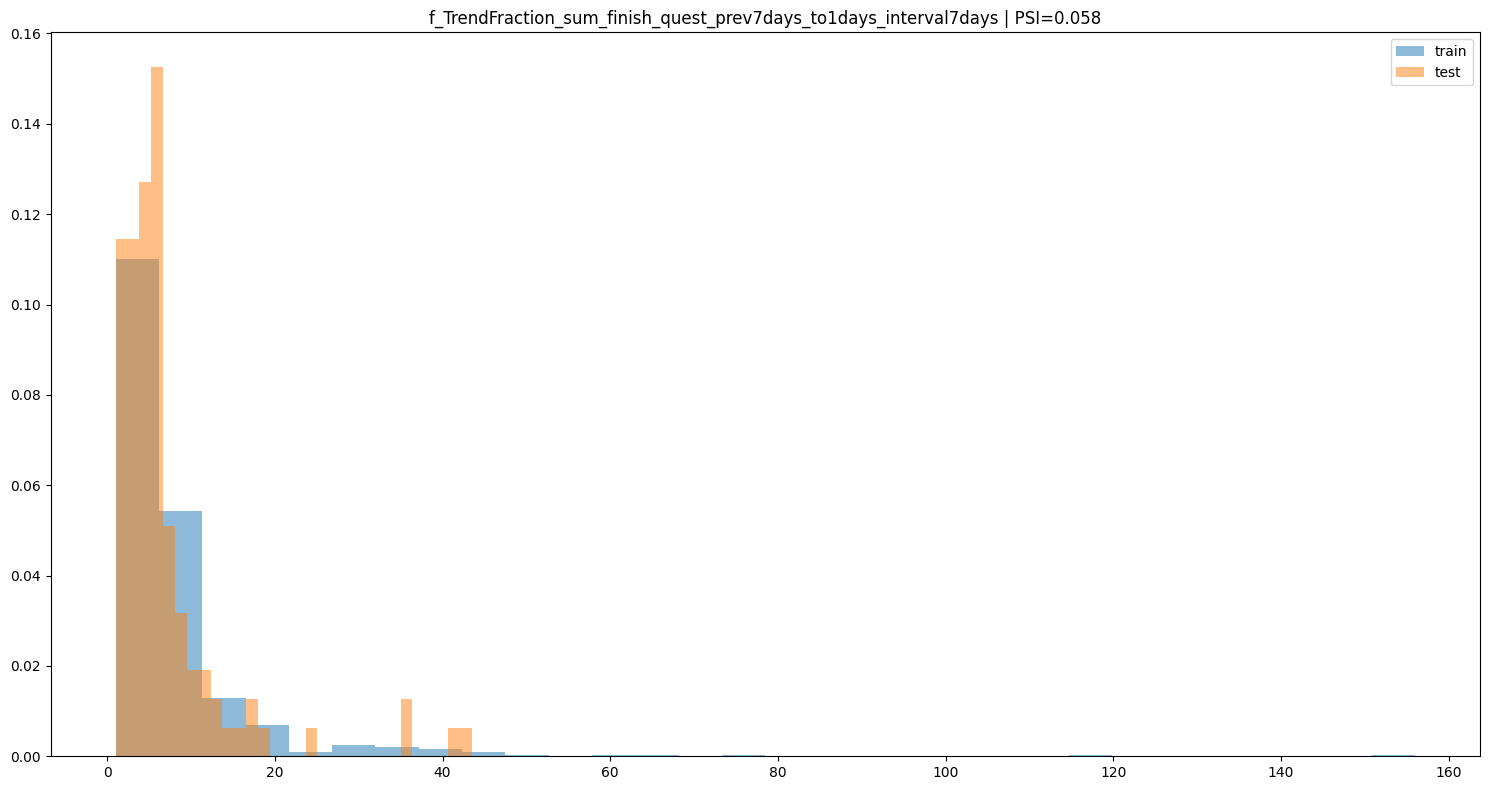

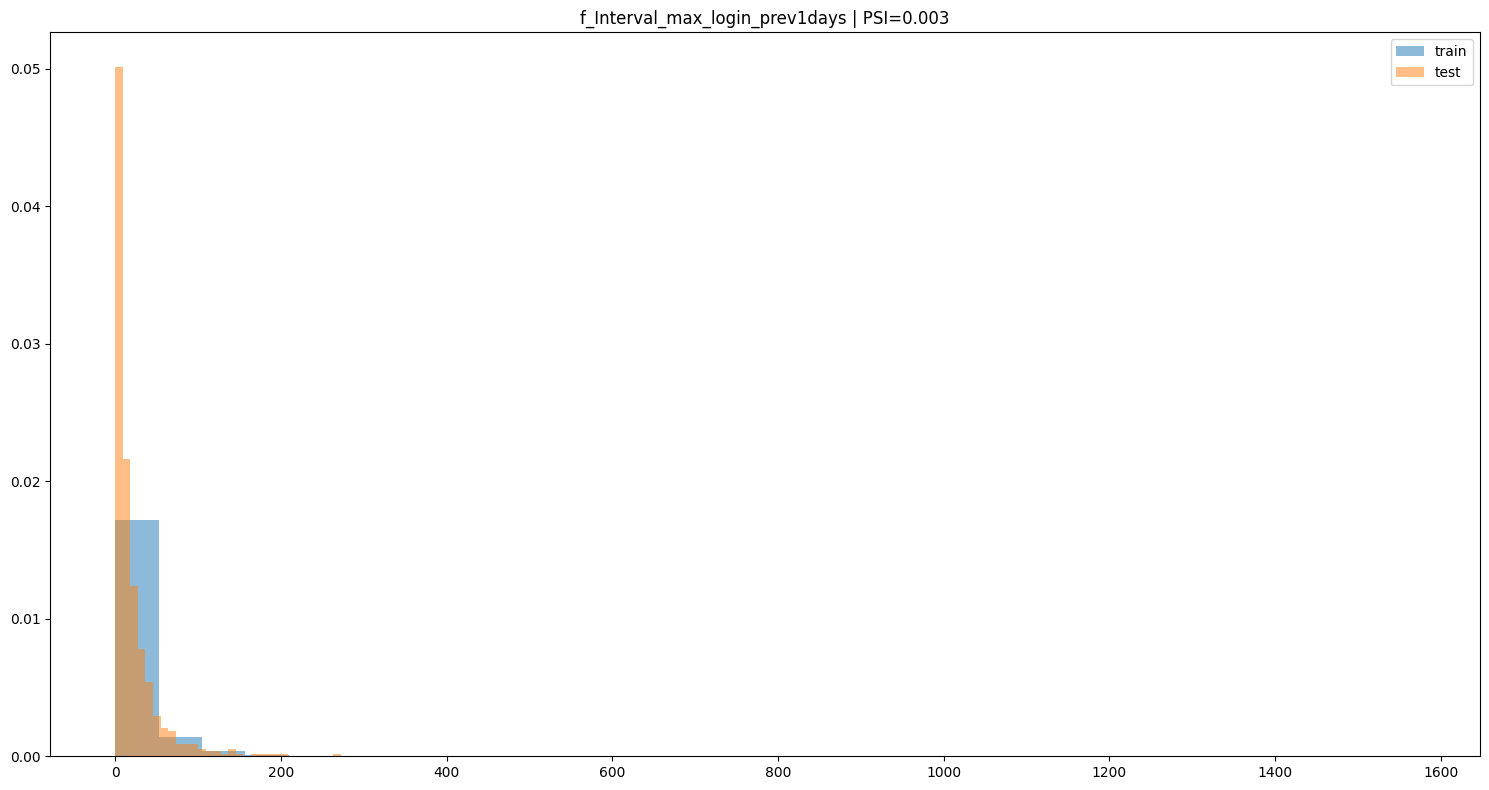

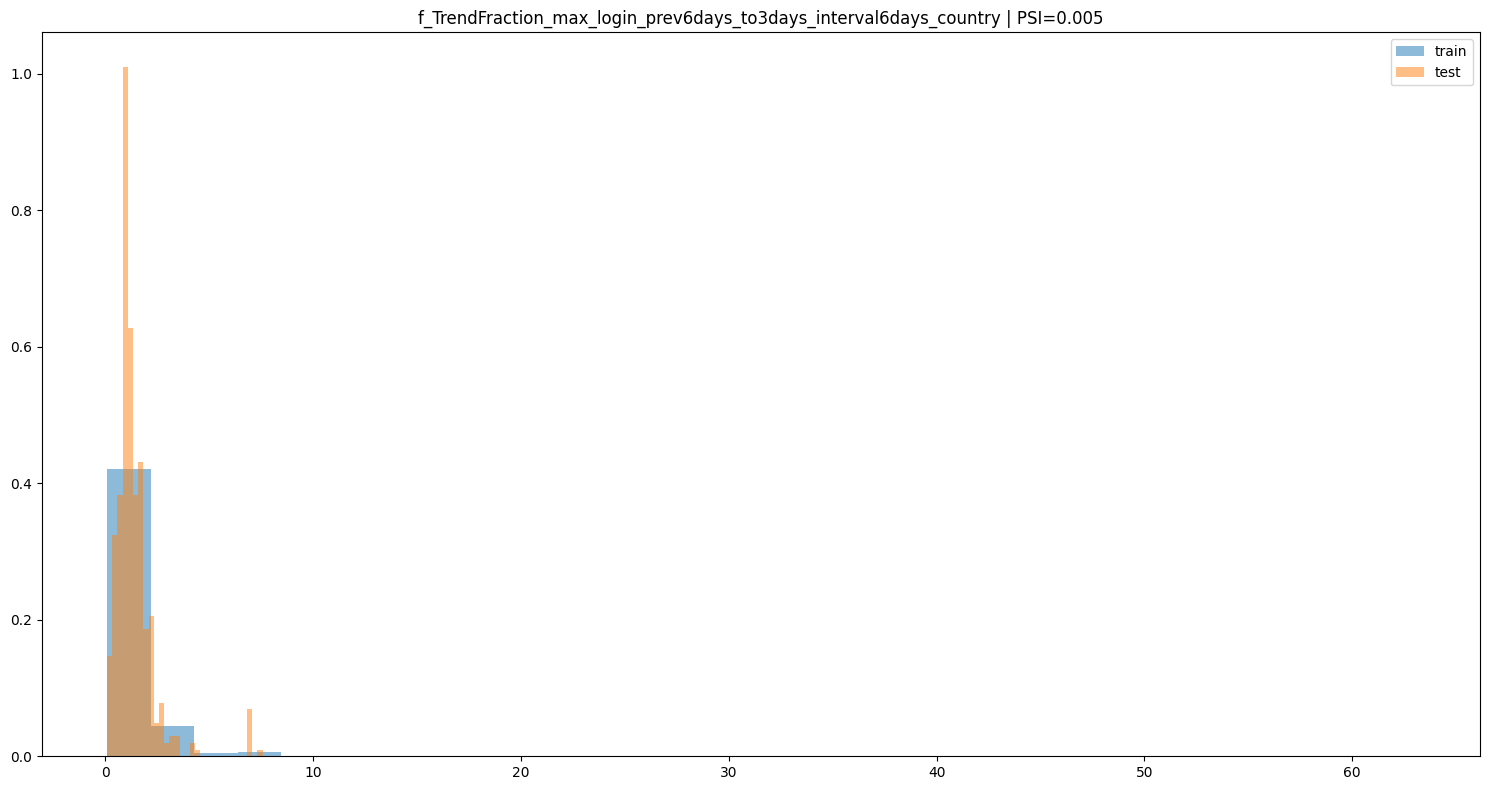

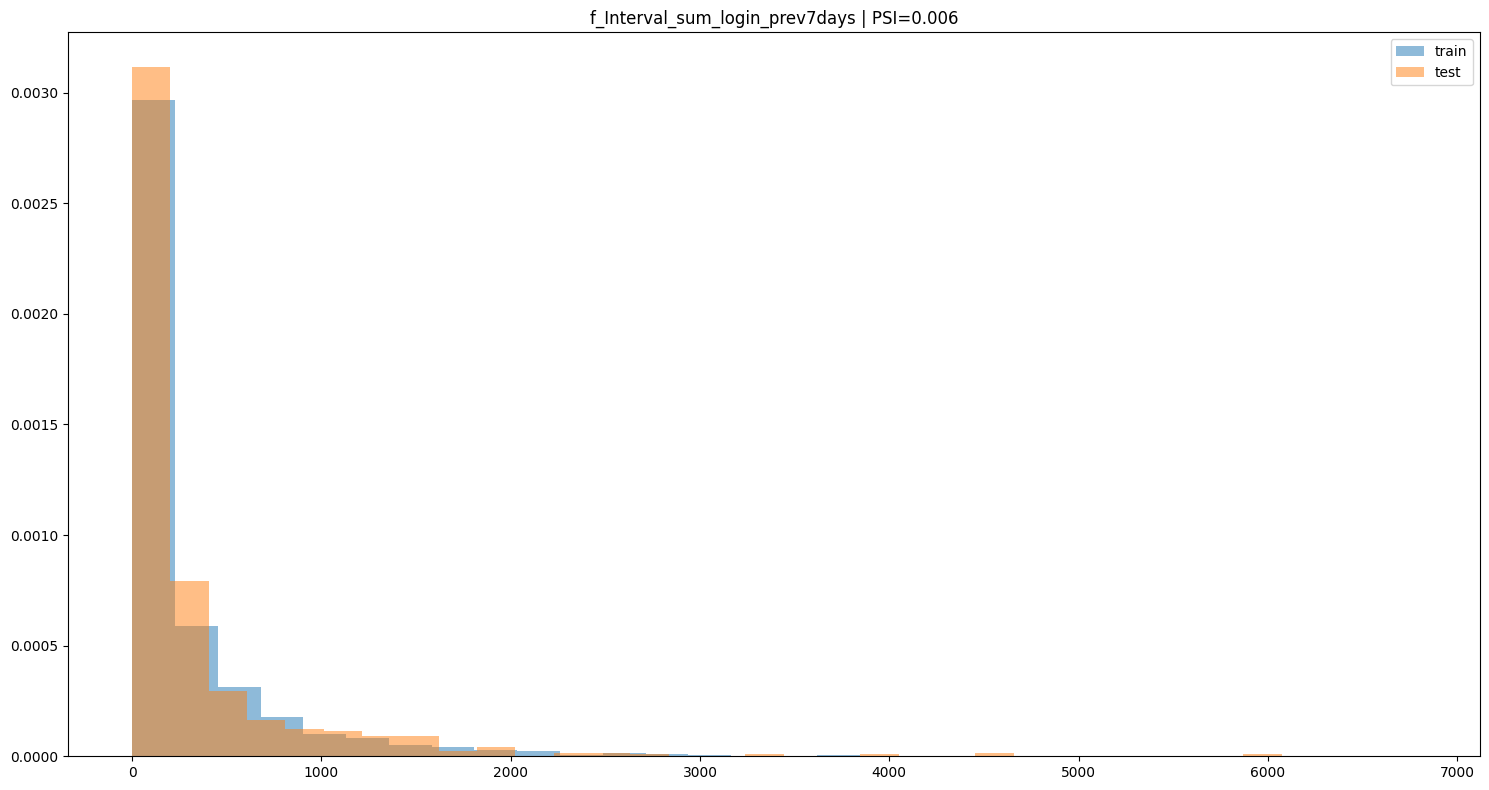

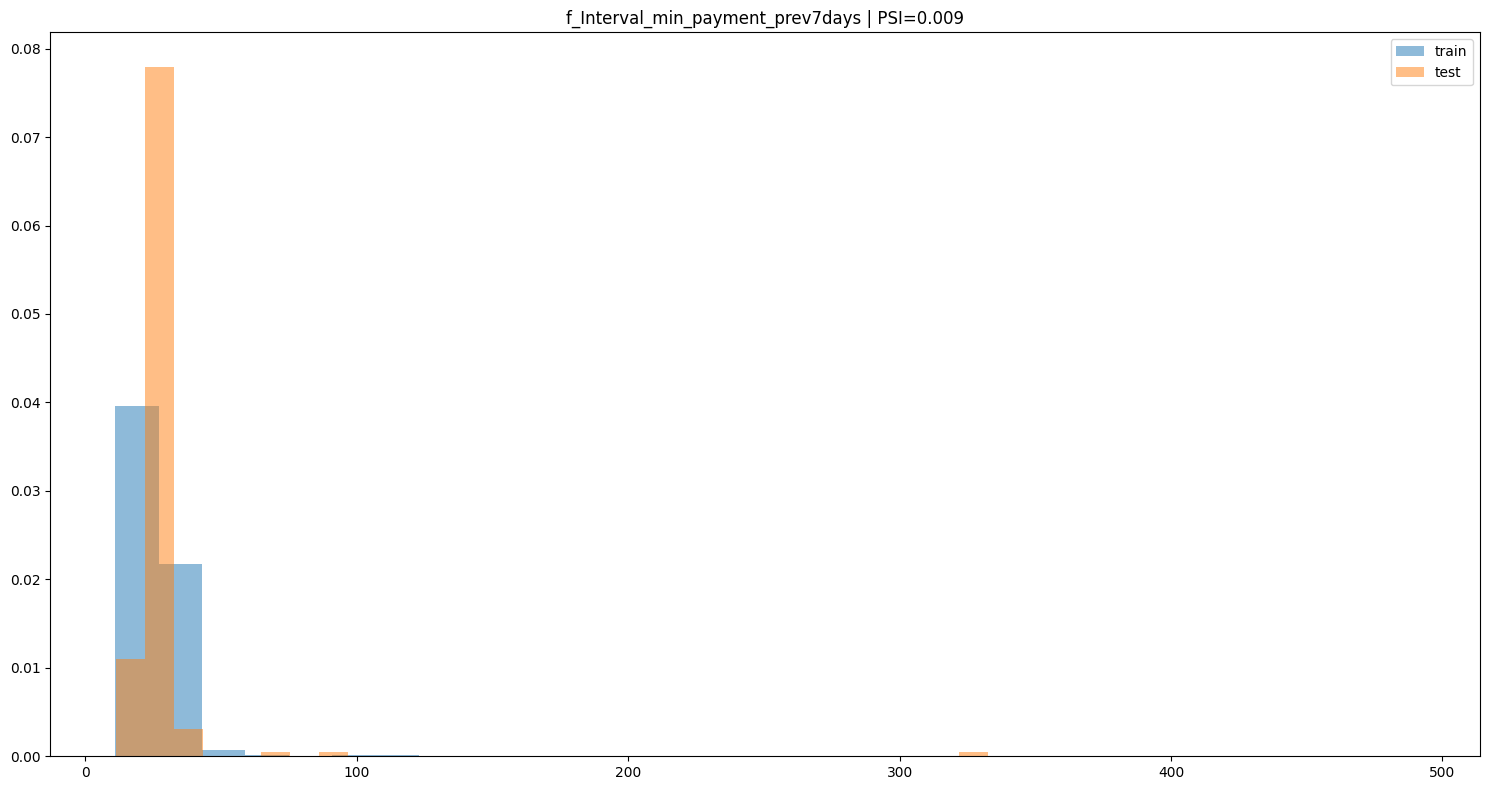

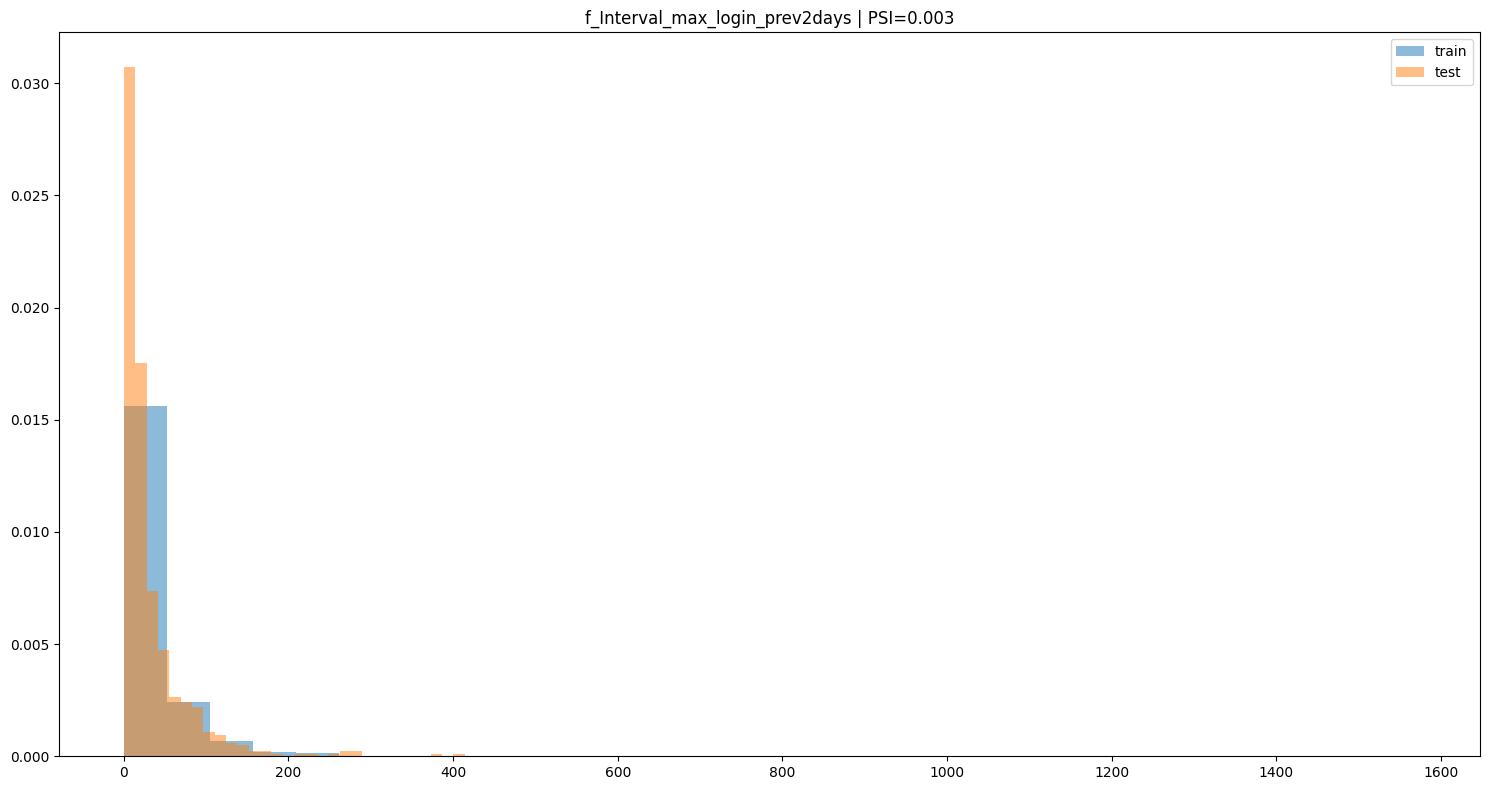

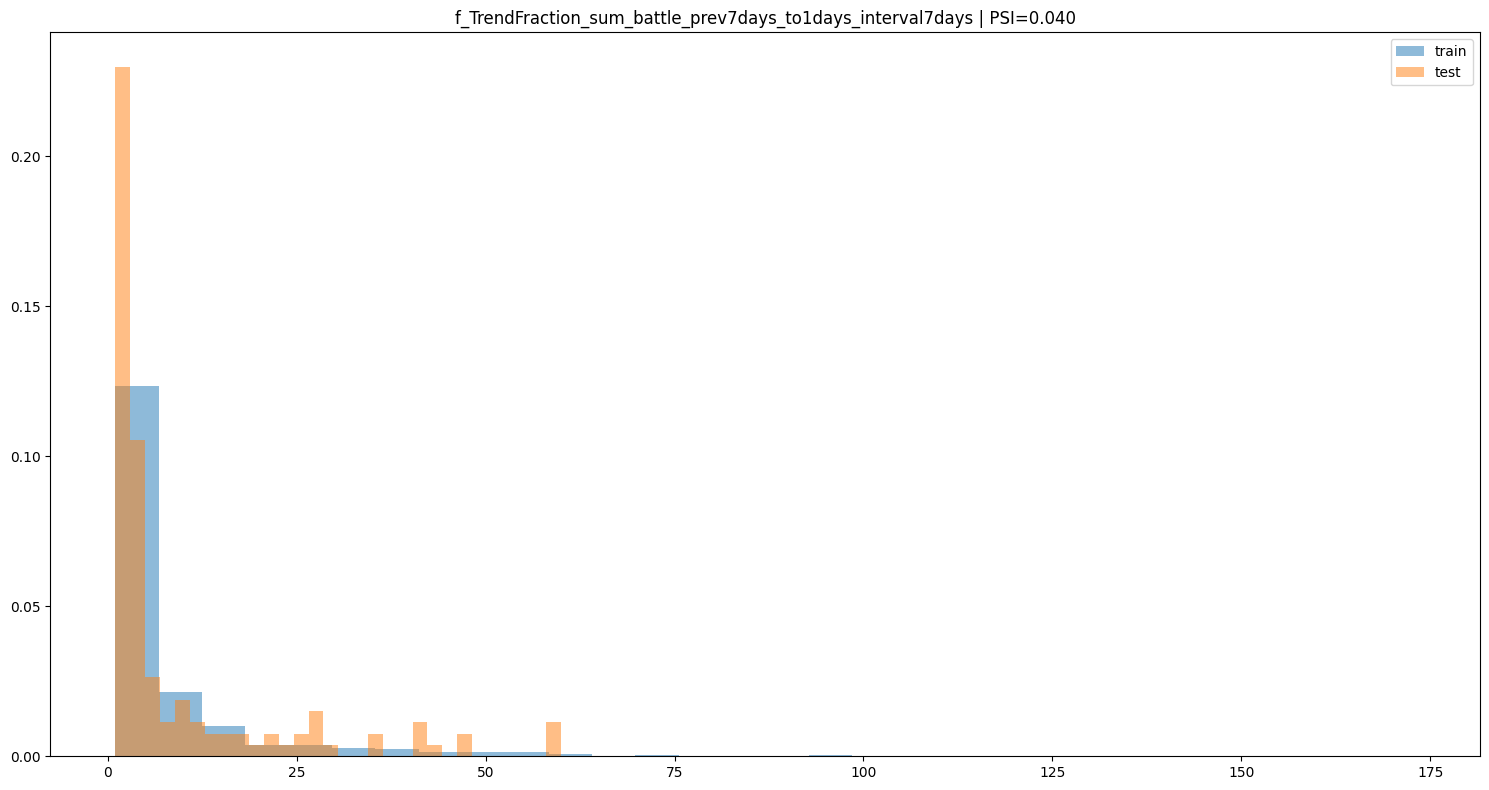

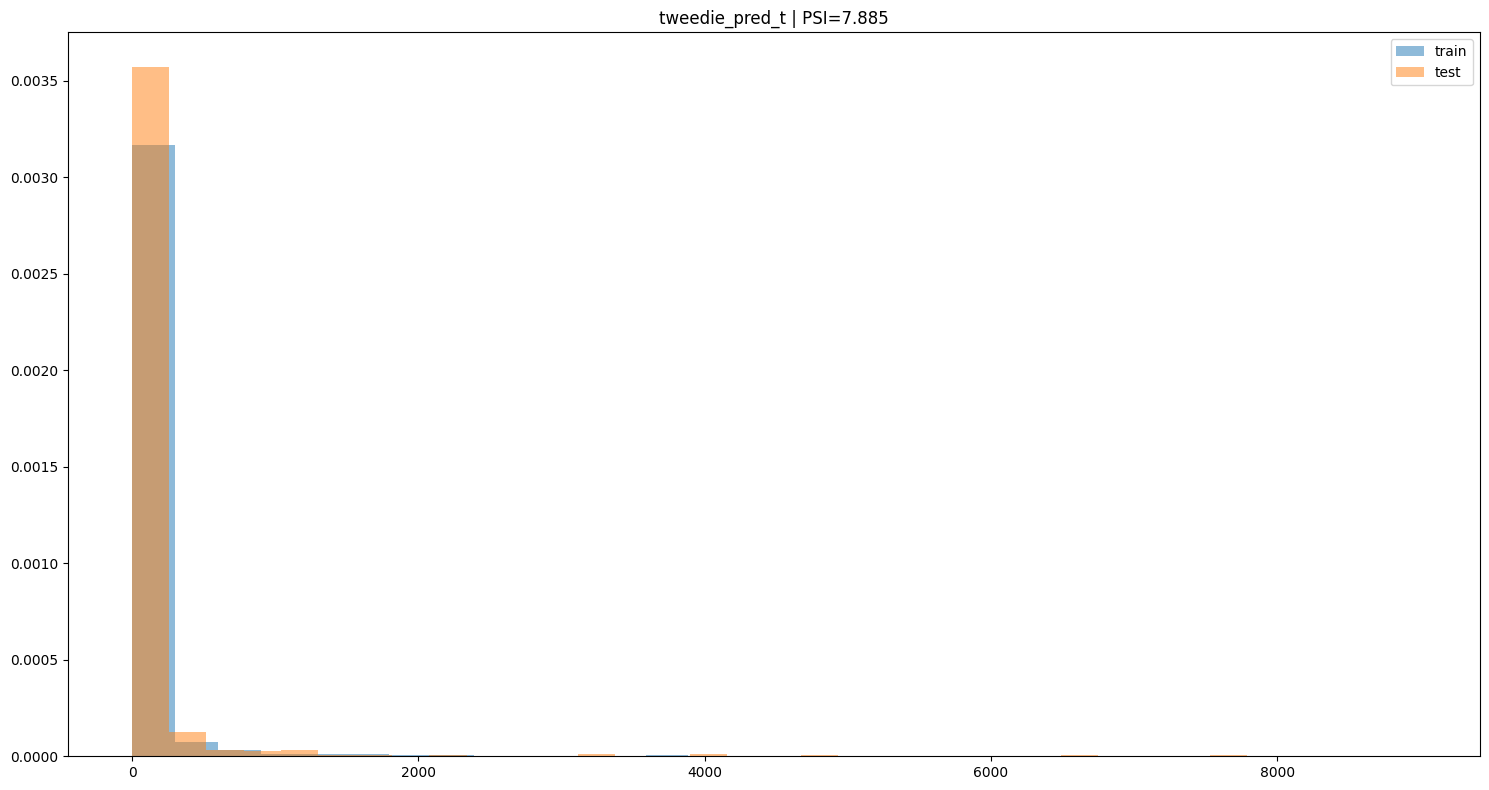

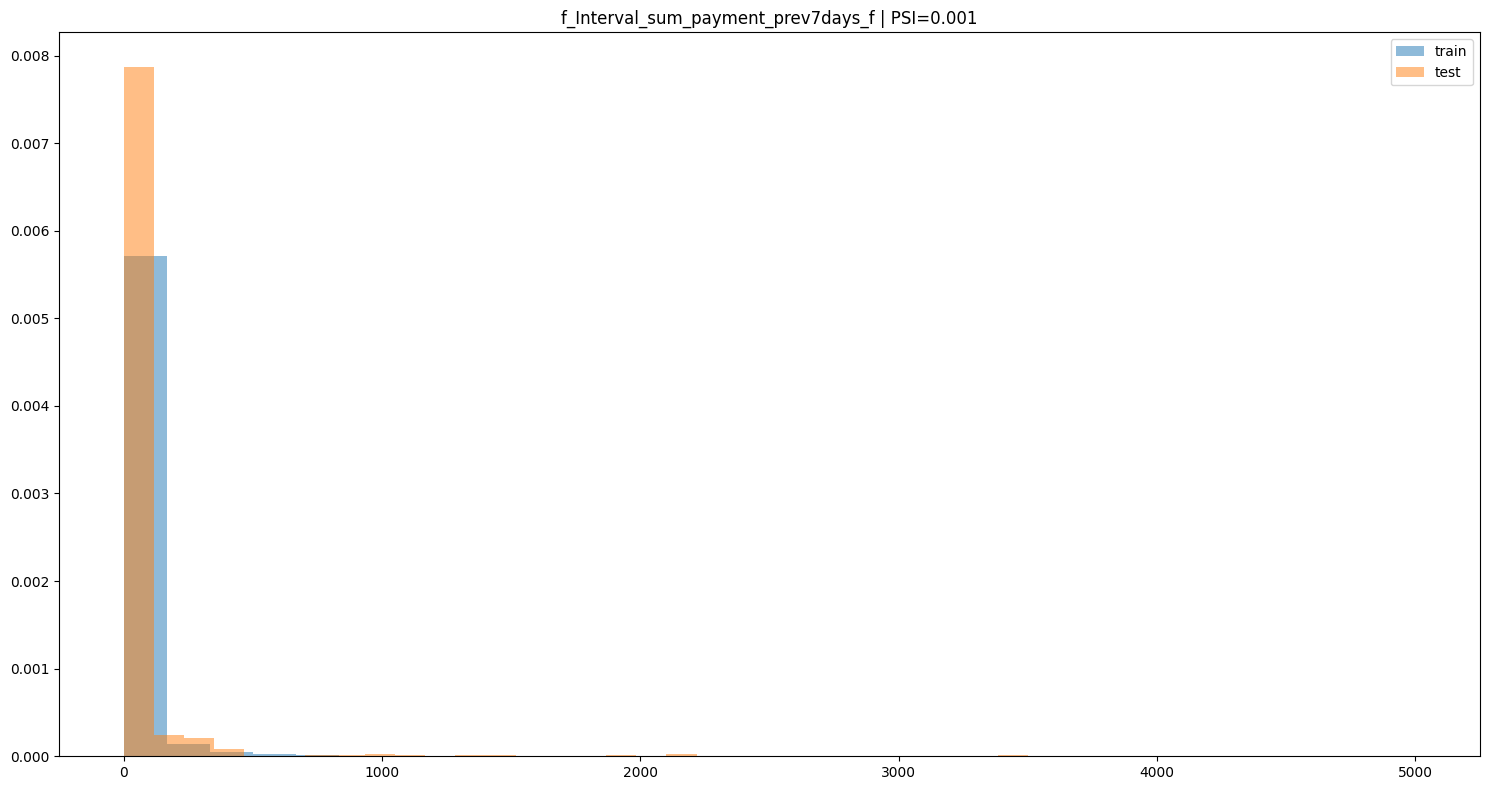

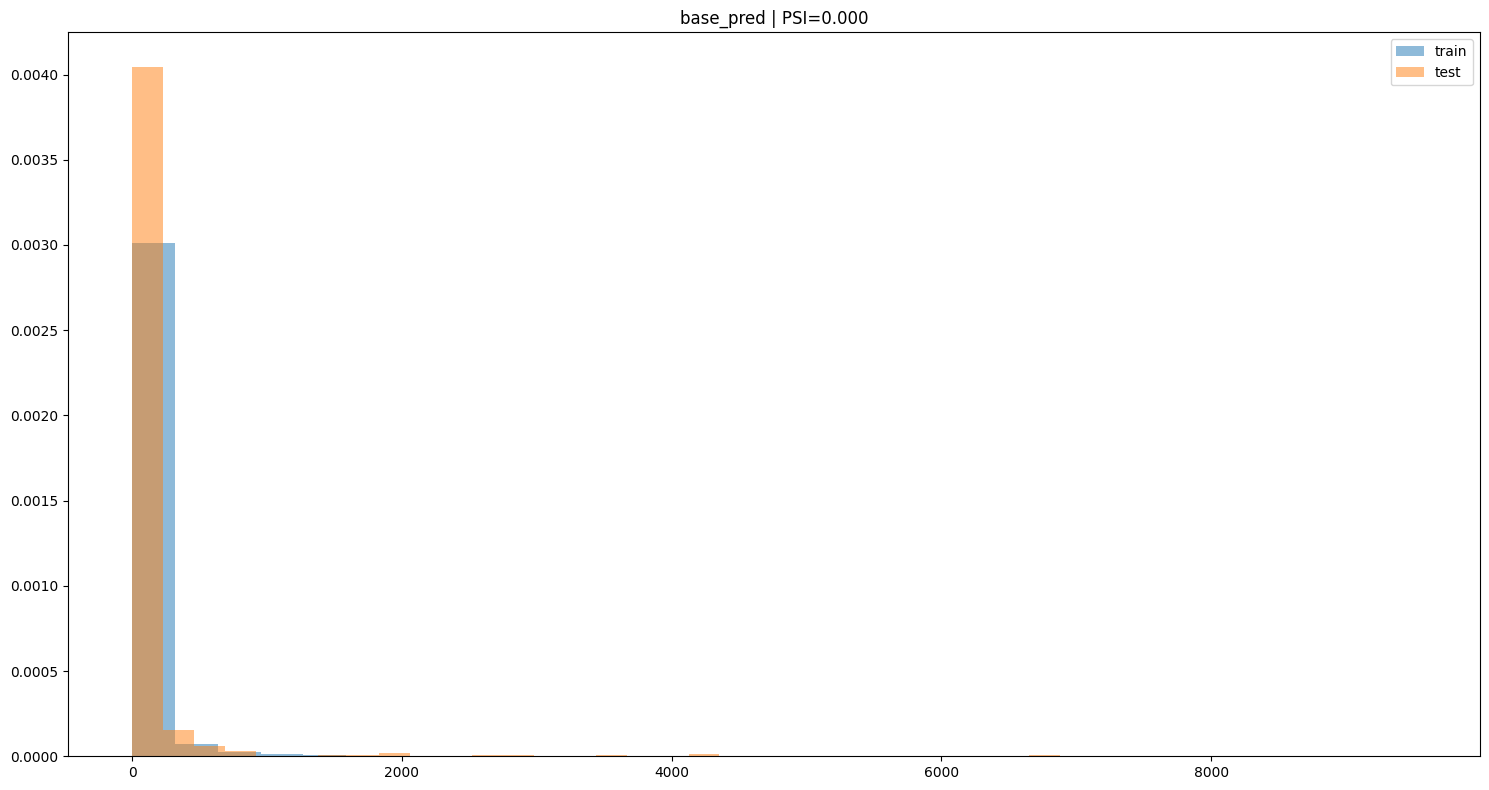

,feature,psi
0,tweedie_pred_t,7.885474e+00
1,f_TrendFraction_sum_finish_quest_prev7days_to1...,5.821017e-02
2,f_TrendFraction_sum_battle_prev6days_to3days_i...,5.025347e-02
3,f_TrendFraction_sum_battle_prev7days_to1days_i...,4.045517e-02
4,f_TrendFraction_sum_battle_prev6days_to2days_i...,3.969504e-02
5,f_MeanFraction_finish_quest_prev7days_to2days,3.933524e-02
6,f_MeanFraction_payment_prev7days_to2days,3.368724e-02
7,f_TrendFraction_sum_payment_prev6days_to3days_...,1.654757e-02
8,f_Interval_sum_payment_prev7days,1.343371e-02
9,f_TrendFraction_max_login_prev7days_to2days_in...,1.227051e-02


In [129]:
psi_report(train, test, features=features+['tweedie_pred_t', 'f_Interval_sum_payment_prev7days_f', 'base_pred'])

In [134]:
test = test.rename(columns={'tweedie_pred_t':'final_score', 'bin_pred':'class_score', 'tweedie_pred':'regr_score'})

In [141]:
test[['reg_ts', 'user_id','country','entry_point', 'final_score', 'class_score', 'regr_score'] + features].to_csv(f"{project_path}/artifacts/final/test.csv")

In [138]:
pd.__version__

'2.2.2'

In [139]:
lgb.__version__

'4.6.0'

In [140]:
np.__version__

'2.0.2'